# LOFO inspection -- PC + NC mean-curve plots, sg_p4 and sg_p4_norm

Covers the 4 mean-curve plotting cells from `0_LOFO_INSPECTION copy.ipynb`
(per-target / per-chip, under PC-TTP and acquisition_start alignment), extended
three ways:

1. **NC-ALL added** alongside the existing PC addition. `config.apply_well_exclusion`
   strips both PC (well 8) and NC-ALL (well 9) out of every LOFO pool for
   `final_6_chip_clean_nn` (same mechanism as PC) -- PC has a `--drop_pc` snapshot
   to re-add from (`pc_wells` in `curve_for_training.joblib`), but NC-ALL has no
   such snapshot, so it's read directly from each chip's raw, unfiltered
   `curve_for_training.joblib` instead (`load_nc_pool`/`load_nc_pool_pc_ttp` below).
2. Each plot's subplot grid is **2 rows** instead of 1.
3. Everything is run for **both** `ori_curve_sg_p4_norm` (original) and
   `ori_curve_sg_p4` (no normalization).

In [1]:
import os, sys, importlib, colorsys, re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(os.path.dirname(notebook_path)))
except Exception as e:
    print(f"Could not change directory: {e}")

print("CWD:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config

# Import-only -- 04_cross_dataset_training.py is not modified.
cdt = importlib.import_module("04_cross_dataset_training")

import tensorflow as tf
# DANN/CORAL models were compiled without jit_compile=False -- XLA's cudnn autotuner can
# spuriously RESOURCE_EXHAUST even on an idle GPU. Not used here, kept for parity with
# 0_LOFO_INSPECTION copy.ipynb since cdt is imported.
tf.config.optimizer.set_jit(False)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.3, 'font.size': 9})
print("Imports OK.")

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main

[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

Imports OK.


## Configuration

In [2]:
GROUP_NAME        = "final_6_new"
EXP_FOLDER        = config.FINAL_EXP_FOLDER
CURVE_TYPES_TO_PLOT = [
    "ori_curve_sg_p4_norm",
    # "ori_curve_sg_p4",
]
CURVE_ALIGNMENT   = "pc_ttp"
PC_TTP_ANCHOR     = "min"

folder_names = config.CROSS_DATASET_GROUPS[GROUP_NAME]
exp_paths = [Path(EXP_FOLDER, name) for name in folder_names]

def short_name(folder):
    m = re.search(r'DDM_0(\d)', folder)
    return f'Chip 0{m.group(1)}' if m else folder.split('_U_', 1)[1]

pc_ttp_cache_dir = Path(EXP_FOLDER) / "cross_dataset_cv" / GROUP_NAME / "_cache_pc_ttp"

print(f"Group '{GROUP_NAME}' -> {len(folder_names)} chips:")
for n in folder_names:
    print(f"  - {n} ({short_name(n)})")

Group 'final_6_new' -> 6 chips:
  - D20260827_E00_C00_F4500KHz_U_DDM_01_final_final (Chip 01)
  - D20260827_E00_C00_F4500KHz_U_DDM_02_final_final (Chip 02)
  - D20260827_E00_C00_F4500KHz_U_DDM_03_final_final (Chip 03)
  - D20260827_E00_C00_F4500KHz_U_DDM_04_final_final (Chip 04)
  - D20260825_E00_C00_F4500KHz_U_DDM_05_01 (Chip 05)
  - D20260825_E00_C00_F4500KHz_U_DDM_06_02 (Chip 06)


## Plot helpers

Both copied from `0_LOFO_INSPECTION copy.ipynb`, with the subplot grid changed
from 1 row to 2 rows (`n_cols = ceil(n/2)`, unused trailing axis hidden if `n`
is odd).

In [3]:
_CATEGORICAL_PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                       "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # fixed order, CVD-checked


def build_well_table(combined):
    df = pd.DataFrame({
        "well_id": combined["well_ids"],
        "dataset_id": combined["dataset_id"],
        "label": combined["Y_mapped"],
    })
    df["row_idx"] = np.arange(len(df))
    meta = df.groupby("well_id").agg(dataset_id=("dataset_id", "first"), label=("label", "first"))
    row_idx_map = df.groupby("well_id")["row_idx"].apply(np.array)
    wells = meta.join(row_idx_map.rename("row_idx")).reset_index()
    wells["n_pixels"] = wells["row_idx"].apply(len)
    return wells


def _shade(base_color, frac, spread=0.3):
    """base_color: any matplotlib-recognized color (hex string, RGB(A) tuple, ...)."""
    h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(base_color))
    l = min(0.85, max(0.15, l + (frac - 0.5) * spread))
    return colorsys.hls_to_rgb(h, l, s)


def _exp_colors(exp_names):
    return {n: _CATEGORICAL_PALETTE[i % len(_CATEGORICAL_PALETTE)] for i, n in enumerate(exp_names)}


def _exp_legend(fig, exp_color, exp_names, y_anchor=-0.02):
    handles = [plt.Line2D([0], [0], color=exp_color[n], lw=2, label=short_name(n))
              for n in exp_names]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(exp_names), 4),
              fontsize=8, bbox_to_anchor=(0.5, y_anchor), frameon=True)


def _raw_conc(combined, well_row):
    conc = combined.get("concentration_raw")
    if conc is None:
        return None
    val = conc[well_row["row_idx"][0]]
    try:
        return float(val)
    except (TypeError, ValueError):
        return None


def plot_target_across_chips(combined, label_order=None, figsize_per_cell=(6, 4),
                             title=None, alpha_indiv=0.10, with_all_curves=True,
                             sharey=False, y_scale=None, non_amp_filter=False):
    """1 label = 1 plot, mean curve per well, colored by chip. 2-row subplot grid."""
    wells = build_well_table(combined)
    exp_names = sorted(wells["dataset_id"].unique())
    exp_color = _exp_colors(exp_names)

    labels_seen = list(dict.fromkeys(wells.sort_values("dataset_id")["label"]))
    if label_order is not None:
        all_labels = [l for l in label_order if l in labels_seen]
        all_labels += [l for l in labels_seen if l not in all_labels]
    else:
        nc    = [l for l in labels_seen if str(l).startswith("NC")]
        nonnc = [l for l in labels_seen if not str(l).startswith("NC")]
        all_labels = sorted(nonnc) + sorted(nc)

    t = np.asarray(combined["resampler"].t_grid, dtype=float)
    n = len(all_labels)
    n_cols = (n + 1) // 2
    fig, axes = plt.subplots(2, n_cols, figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1]*1.35*2),
                             squeeze=False, sharey="row" if sharey else False)
    axes = axes.flatten()
    for extra_ax in axes[n:]:
        extra_ax.set_visible(False)

    for ax, label in zip(axes, all_labels):
        label_wells = wells[wells["label"] == label].copy()
        label_wells["_conc"] = [_raw_conc(combined, w) for _, w in label_wells.iterrows()]
        concs_sorted = sorted({c for c in label_wells["_conc"] if c is not None})
        n_concs = len(concs_sorted)

        for _, w in label_wells.iterrows():
            idx = w["row_idx"]
            curves = combined["curves"][idx]
            conc = w["_conc"]

            if non_amp_filter:
                keep = curves[:, -1] >= curves[:, 0]
                curves = curves[keep]
                if len(curves) == 0:
                    continue

            mean = curves.mean(axis=0)
            frac = (concs_sorted.index(conc) / (n_concs - 1)) if (conc is not None and n_concs > 1) else 0.5
            color = _shade(exp_color[w["dataset_id"]], 0.5)

            if with_all_curves:
                step = max(1, len(curves) // 30)
                for c in curves[::step]:
                    ax.plot(t, c, color=color, lw=0.4, alpha=alpha_indiv, rasterized=True)
            ax.plot(t, mean, color=color, lw=1.5)

        ax.set_title(str(label), fontsize=14, fontweight="bold")
        ax.set_xlabel("Time", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.tick_params(labelsize=7)
        if y_scale is not None:
            ax.set_ylim(*y_scale)

    axes[0].set_ylabel("Signal", fontsize=9)
    if n > n_cols:
        axes[n_cols].set_ylabel("Signal", fontsize=9)
    fig.suptitle(title or "Same target across chips  (colour=chip, shade=concentration)",
                fontsize=12, fontweight="bold")
    _exp_legend(fig, exp_color, exp_names)
    plt.tight_layout(rect=[0, 0.08, 1, 0.93])
    plt.show()

In [4]:
def _label_colors(labels):
    return {l: _CATEGORICAL_PALETTE[i % len(_CATEGORICAL_PALETTE)] for i, l in enumerate(labels)}


def _label_legend(fig, label_color, labels, y_anchor=-0.02):
    handles = [plt.Line2D([0], [0], color=label_color[l], lw=2, label=str(l))
              for l in labels]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(labels), 4),
              fontsize=8, bbox_to_anchor=(0.5, y_anchor), frameon=True)


def plot_chip_across_targets(combined, label_order=None, figsize_per_cell=(6, 4),
                             title=None, alpha_indiv=0.10, with_all_curves=True,
                             sharey=False, y_scale=None, non_amp_filter=False):
    """Mirrors plot_target_across_chips with the subplot axis and colour-by axis
    swapped -- 1 chip = 1 plot, mean curve per well, colored by target. 2-row grid."""
    wells = build_well_table(combined)
    exp_names = sorted(wells["dataset_id"].unique())

    labels_seen = list(dict.fromkeys(wells.sort_values("dataset_id")["label"]))
    if label_order is not None:
        all_labels = [l for l in label_order if l in labels_seen]
        all_labels += [l for l in labels_seen if l not in all_labels]
    else:
        nc    = [l for l in labels_seen if str(l).startswith("NC")]
        nonnc = [l for l in labels_seen if not str(l).startswith("NC")]
        all_labels = sorted(nonnc) + sorted(nc)
    label_color = _label_colors(all_labels)

    t = np.asarray(combined["resampler"].t_grid, dtype=float)
    n = len(exp_names)
    n_cols = (n + 1) // 2
    fig, axes = plt.subplots(2, n_cols, figsize=(figsize_per_cell[0] * n_cols, figsize_per_cell[1]*1.35*2),
                             squeeze=False, sharey="row" if sharey else False)
    axes = axes.flatten()
    for extra_ax in axes[n:]:
        extra_ax.set_visible(False)

    for ax, exp_name in zip(axes, exp_names):
        exp_wells = wells[wells["dataset_id"] == exp_name]

        for _, w in exp_wells.iterrows():
            idx = w["row_idx"]
            curves = combined["curves"][idx]

            if non_amp_filter:
                keep = curves[:, -1] >= curves[:, 0]
                curves = curves[keep]
                if len(curves) == 0:
                    continue

            mean = curves.mean(axis=0)
            color = _shade(label_color[w["label"]], 0.5)

            if with_all_curves:
                step = max(1, len(curves) // 30)
                for c in curves[::step]:
                    ax.plot(t, c, color=color, lw=0.4, alpha=alpha_indiv, rasterized=True)
            ax.plot(t, mean, color=color, lw=1.5)

        ax.set_title(short_name(exp_name), fontsize=14, fontweight="bold")
        ax.set_xlabel("Time", fontsize=8)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.tick_params(labelsize=7)
        if y_scale is not None:
            ax.set_ylim(*y_scale)

    axes[0].set_ylabel("Signal", fontsize=9)
    if n > n_cols:
        axes[n_cols].set_ylabel("Signal", fontsize=9)
    fig.suptitle(title or "Same chip across targets  (colour=target)",
                fontsize=12, fontweight="bold")
    _label_legend(fig, label_color, all_labels)
    plt.tight_layout(rect=[0, 0.08, 1, 0.93])
    plt.show()


def _non_control_labels(labels_seen, label_order=None):
    """labels_seen with PC/NC* dropped -- shared by the chip-agnostic target plots."""
    excluded = {l for l in labels_seen if str(l).startswith("NC") or l == "PC"}
    if label_order is not None:
        all_labels = [l for l in label_order if l in labels_seen and l not in excluded]
        all_labels += [l for l in labels_seen if l not in all_labels and l not in excluded]
    else:
        all_labels = sorted(l for l in labels_seen if l not in excluded)
    return all_labels


def plot_all_targets_all_chips(combined, label_order=None, figsize=(9, 6),
                               title=None, alpha_indiv=0.10, with_all_curves=False,
                               y_scale=None, non_amp_filter=False):
    """1 plot: every well's mean curve on shared axes, colour = target only
    (chip-agnostic) -- for comparing curve-shape similarity for the same target
    across different chips. PC/NC-ALL excluded."""
    wells = build_well_table(combined)
    labels_seen = list(dict.fromkeys(wells.sort_values("dataset_id")["label"]))
    all_labels = _non_control_labels(labels_seen, label_order)
    wells = wells[wells["label"].isin(all_labels)]
    label_color = _label_colors(all_labels)

    t = np.asarray(combined["resampler"].t_grid, dtype=float)
    fig, ax = plt.subplots(figsize=figsize)

    seen = set()
    for _, w in wells.iterrows():
        idx = w["row_idx"]
        curves = combined["curves"][idx]

        if non_amp_filter:
            keep = curves[:, -1] >= curves[:, 0]
            curves = curves[keep]
            if len(curves) == 0:
                continue

        mean = curves.mean(axis=0)
        color = _shade(label_color[w["label"]], 0.5)

        if with_all_curves:
            step = max(1, len(curves) // 30)
            for c in curves[::step]:
                ax.plot(t, c, color=color, lw=0.4, alpha=alpha_indiv, rasterized=True)
        ax.plot(t, mean, color=color, lw=1.2, label=None if w["label"] in seen else str(w["label"]))
        seen.add(w["label"])

    ax.set_xlabel("Time", fontsize=9)
    ax.set_ylabel("Signal", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.tick_params(labelsize=8)
    if y_scale is not None:
        ax.set_ylim(*y_scale)
    ax.legend(title="target", fontsize=8, framealpha=0.85, loc="upper right")
    fig.suptitle(title or "All targets, all chips  (colour=target, chip-agnostic)",
                fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_target_pairwise_grid(combined, label_order=None, figsize_per_cell=(2.6, 2.6),
                              title=None, alpha_indiv=0.10, with_all_curves=False,
                              non_amp_filter=False):
    """N x N grid (N = non-control targets): cell (row=target_y, col=target_x)
    overlays every well's mean curve for target_x and target_y (colour = target,
    all chips/concentrations pooled) -- pairwise curve-shape comparison. Diagonal
    cells show that one target alone. PC/NC-ALL excluded."""
    wells = build_well_table(combined)
    labels_seen = list(dict.fromkeys(wells.sort_values("dataset_id")["label"]))
    targets = _non_control_labels(labels_seen, label_order)
    wells = wells[wells["label"].isin(targets)]
    label_color = _label_colors(targets)

    t = np.asarray(combined["resampler"].t_grid, dtype=float)
    n = len(targets)
    fig, axes = plt.subplots(n, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1] * n),
                             squeeze=False, sharex=True, sharey=True)

    def _plot_target(ax, target):
        for _, w in wells[wells["label"] == target].iterrows():
            idx = w["row_idx"]
            curves = combined["curves"][idx]
            if non_amp_filter:
                keep = curves[:, -1] >= curves[:, 0]
                curves = curves[keep]
                if len(curves) == 0:
                    continue
            mean = curves.mean(axis=0)
            color = label_color[target]
            if with_all_curves:
                step = max(1, len(curves) // 30)
                for c in curves[::step]:
                    ax.plot(t, c, color=color, lw=0.3, alpha=alpha_indiv, rasterized=True)
            ax.plot(t, mean, color=color, lw=1.2)

    for row_i, target_y in enumerate(targets):
        for col_i, target_x in enumerate(targets):
            ax = axes[row_i, col_i]
            _plot_target(ax, target_x)
            if target_x != target_y:
                _plot_target(ax, target_y)
            ax.grid(True, linestyle="--", alpha=0.25)
            ax.tick_params(labelsize=6)
            if row_i == 0:
                ax.set_title(str(target_x), fontsize=9, fontweight="bold")
            if col_i == 0:
                ax.set_ylabel(str(target_y), fontsize=9, fontweight="bold")

    fig.suptitle(title or "Pairwise target comparison  (colour=target)",
                fontsize=12, fontweight="bold")
    _label_legend(fig, label_color, targets)
    plt.tight_layout(rect=[0, 0.05, 1, 0.94])
    plt.show()


def plot_target_pairwise_grid_lofo(combined, held_out_chip, label_order=None,
                                   figsize_per_cell=(2.6, 2.6), title=None,
                                   alpha_indiv=0.10, with_all_curves=False,
                                   non_amp_filter=False):
    """N x N grid: col = target as seen in the HELD-OUT chip only (black, drawn on
    top), row = same target list as seen in the TRAINED (non-held-out) chips
    (colour = target). Diagonal = does the held-out chip's own target match its
    trained counterpart; off-diagonal = does it get confused with another trained
    target. PC/NC excluded."""
    wells = build_well_table(combined)
    labels_seen = list(dict.fromkeys(wells.sort_values("dataset_id")["label"]))
    targets = _non_control_labels(labels_seen, label_order)
    wells = wells[wells["label"].isin(targets)]
    label_color = _label_colors(targets)

    trained_wells = wells[wells["dataset_id"] != held_out_chip]
    held_out_wells = wells[wells["dataset_id"] == held_out_chip]

    t = np.asarray(combined["resampler"].t_grid, dtype=float)
    n = len(targets)
    fig, axes = plt.subplots(n, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1] * n),
                             squeeze=False, sharex=True, sharey=True)

    def _plot_wells(ax, wells_df, target, color, zorder, lw):
        for _, w in wells_df[wells_df["label"] == target].iterrows():
            idx = w["row_idx"]
            curves = combined["curves"][idx]
            if non_amp_filter:
                keep = curves[:, -1] >= curves[:, 0]
                curves = curves[keep]
                if len(curves) == 0:
                    continue
            mean = curves.mean(axis=0)
            if with_all_curves:
                step = max(1, len(curves) // 30)
                for c in curves[::step]:
                    ax.plot(t, c, color=color, lw=0.3, alpha=alpha_indiv, rasterized=True, zorder=zorder)
            ax.plot(t, mean, color=color, lw=lw, zorder=zorder)

    for row_i, target_row in enumerate(targets):      # held-out target
        for col_j, target_col in enumerate(targets):  # trained target
            ax = axes[row_i, col_j]
            _plot_wells(ax, trained_wells, target_col, label_color[target_col], zorder=2, lw=1.2)
            _plot_wells(ax, held_out_wells, target_row, "black", zorder=5, lw=1.6)
            ax.grid(True, linestyle="--", alpha=0.25)
            ax.tick_params(labelsize=6)
            if row_i == 0:
                ax.set_title(str(target_col), fontsize=9, fontweight="bold")
            if col_j == 0:
                ax.set_ylabel(str(target_row), fontsize=9, fontweight="bold")

    fig.suptitle(title or (f"LOFO check -- held-out={short_name(held_out_chip)}\n"
                           "cols=trained target (colour), rows=held-out target (black)"),
                fontsize=12, fontweight="bold")
    handles = [plt.Line2D([0], [0], color=label_color[l], lw=2, label=str(l)) for l in targets]
    handles.append(plt.Line2D([0], [0], color="black", lw=2, label="held-out"))
    fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 6),
              fontsize=8, bbox_to_anchor=(0.5, -0.02), frameon=True)
    plt.tight_layout(rect=[0, 0.06, 1, 0.93])
    plt.show()


## PC pool loaders (copied unmodified from `0_LOFO_INSPECTION copy.ipynb`)

In [5]:
def load_pc_pool(exp_paths, curve_type, resampler):
    """Loads each chip's dropped PC curves (01's --drop_pc snapshot, via
    cdt.load_pc_wells_snapshot) and resamples them onto `resampler`'s common
    grid -- so PC can be concatenated in as an ordinary 'PC' well per chip and
    rendered by the existing plot_target_across_chips unmodified."""
    curves_parts, dataset_id_parts, well_id_parts = [], [], []
    for exp_path in exp_paths:
        pc = cdt.load_pc_wells_snapshot(exp_path, curve_type)
        if pc is None:
            continue
        t_zeroed = pc["timestamps"] - pc["timestamps"][0]
        curves_resampled = resampler.transform(t_zeroed, pc["curves"])
        n = len(curves_resampled)
        curves_parts.append(curves_resampled)
        dataset_id_parts.append(np.full(n, exp_path.name, dtype=object))
        well_id_parts.append(np.full(n, f"{exp_path.name}_PC", dtype=object))
    if not curves_parts:
        return None
    n_total = sum(len(c) for c in curves_parts)
    return {
        "curves": np.concatenate(curves_parts, axis=0),
        "dataset_id": np.concatenate(dataset_id_parts, axis=0),
        "well_ids": np.concatenate(well_id_parts, axis=0),
        "Y_mapped": np.full(n_total, "PC", dtype=object),
        "concentration_raw": np.full(n_total, None, dtype=object),
    }


def with_pc_added(combined, exp_paths, curve_type):
    pc_pool = load_pc_pool(exp_paths, curve_type, combined["resampler"])
    if pc_pool is None:
        print("  [!] No PC snapshot found for any chip (--drop_pc not used?).")
        return combined
    merged = dict(combined)
    for key in ["curves", "dataset_id", "well_ids", "Y_mapped", "concentration_raw"]:
        merged[key] = np.concatenate([combined[key], pc_pool[key]], axis=0)
    return merged

In [6]:
def load_pc_pool_pc_ttp(exp_paths, curve_type, combined):
    """Same idea as load_pc_pool, but for a PC-TTP-aligned `combined` pool (built via
    cdt.combine_group_pc_aligned): each chip's PC curves get the identical
    shift_to_pc_ttp_anchor + truncate_to_common_duration treatment as the main curves,
    using the anchor/common_duration/pc_ttp_per_chip already stored in
    combined['pc_ttp_recipe'], so PC lands on the same (shifted+truncated) time axis as
    everything else in this pool."""
    recipe = combined["pc_ttp_recipe"]
    resampler = combined["resampler"]
    curves_parts, dataset_id_parts, well_id_parts = [], [], []
    for exp_path in exp_paths:
        pc = cdt.load_pc_wells_snapshot(exp_path, curve_type)
        if pc is None:
            continue
        ttp = recipe["pc_ttp_per_chip"].get(exp_path.name)
        pc_t, pc_c, _ = cdt.shift_to_pc_ttp_anchor(pc["timestamps"], pc["curves"], ttp, recipe["anchor"])
        pc_t, pc_c = cdt.truncate_to_common_duration(pc_t, pc_c, recipe["common_duration"])
        curves_resampled = resampler.transform(pc_t, pc_c)
        if curve_type.endswith("_norm"):
            curves_resampled = cdt.normalize_curves_minmax(curves_resampled)
        n = len(curves_resampled)
        curves_parts.append(curves_resampled)
        dataset_id_parts.append(np.full(n, exp_path.name, dtype=object))
        well_id_parts.append(np.full(n, f"{exp_path.name}_PC", dtype=object))
    if not curves_parts:
        return None
    n_total = sum(len(c) for c in curves_parts)
    return {
        "curves": np.concatenate(curves_parts, axis=0),
        "dataset_id": np.concatenate(dataset_id_parts, axis=0),
        "well_ids": np.concatenate(well_id_parts, axis=0),
        "Y_mapped": np.full(n_total, "PC", dtype=object),
        "concentration_raw": np.full(n_total, None, dtype=object),
    }


def with_pc_added_pc_ttp(combined, exp_paths, curve_type):
    pc_pool = load_pc_pool_pc_ttp(exp_paths, curve_type, combined)
    if pc_pool is None:
        print("  [!] No PC snapshot found for any chip (--drop_pc not used?).")
        return combined
    merged = dict(combined)
    for key in ["curves", "dataset_id", "well_ids", "Y_mapped", "concentration_raw"]:
        merged[key] = np.concatenate([combined[key], pc_pool[key]], axis=0)
    return merged

## NC-ALL pool loaders (new)

`config.apply_well_exclusion` strips well 9 (NC-ALL) out of every LOFO pool for
`final_6_chip_clean_nn`, the same way it strips well 8 (PC) -- confirmed via
`04_cross_dataset_training.py`'s `load_curve_data`, which calls
`config.apply_well_exclusion(data, exp_path.name, group_name=group_name)` as its
first step. Unlike PC, NC-ALL has no separate `--drop_pc`-style snapshot in
`curve_for_training.joblib` -- it lives directly in the main `dataset`/`Y_well`
arrays and is only removed downstream by `apply_well_exclusion`. So these loaders
re-derive it by reading each chip's **raw, unfiltered** `curve_for_training.joblib`
directly (bypassing `apply_well_exclusion`/`load_curve_data` entirely) and
filtering to rows whose mapped label is `"NC-ALL"` (`config.LABEL_MAPPINGS` maps
well 9 -> `"NC-ALL"` for every chip in this group). Otherwise mirrors
`load_pc_pool`/`load_pc_pool_pc_ttp` exactly.

In [7]:
def _load_nc_rows(exp_path, curve_type):
    """Raw (unfiltered by apply_well_exclusion) NC-ALL curves + timestamps for one chip,
    or None if unavailable. Mirrors load_curve_data's own curve-type resolution and
    label-mapping steps, just without the well-exclusion step."""
    data_path = os.path.join(exp_path, config.TRAINING_DATA_PATH)
    if not os.path.exists(data_path):
        return None
    data = joblib.load(data_path)
    dataset_name = list(data["dataset_name"])
    try:
        idx, _ = config.resolve_curve_dataset_idx(curve_type, dataset_name)
    except ValueError:
        return None
    label_mappings = config.get_label_mappings(exp_path)
    if exp_path.name not in label_mappings:
        return None
    mapping = label_mappings[exp_path.name]
    Y_well_raw = np.asarray(data["Y_well"])
    Y_mapped = np.array([mapping.get(w, w) for w in Y_well_raw])
    nc_mask = Y_mapped == "NC-ALL"
    if not nc_mask.any():
        return None
    return {
        "curves": data["dataset"][idx][nc_mask],
        "timestamps": np.asarray(data["timestamps"], dtype=float),
    }


def load_nc_pool(exp_paths, curve_type, resampler):
    """NC-ALL analogue of load_pc_pool -- acquisition_start alignment."""
    curves_parts, dataset_id_parts, well_id_parts = [], [], []
    for exp_path in exp_paths:
        nc = _load_nc_rows(exp_path, curve_type)
        if nc is None:
            continue
        t_zeroed = nc["timestamps"] - nc["timestamps"][0]
        curves_resampled = resampler.transform(t_zeroed, nc["curves"])
        n = len(curves_resampled)
        curves_parts.append(curves_resampled)
        dataset_id_parts.append(np.full(n, exp_path.name, dtype=object))
        well_id_parts.append(np.full(n, f"{exp_path.name}_NC-ALL", dtype=object))
    if not curves_parts:
        return None
    n_total = sum(len(c) for c in curves_parts)
    return {
        "curves": np.concatenate(curves_parts, axis=0),
        "dataset_id": np.concatenate(dataset_id_parts, axis=0),
        "well_ids": np.concatenate(well_id_parts, axis=0),
        "Y_mapped": np.full(n_total, "NC-ALL", dtype=object),
        "concentration_raw": np.full(n_total, None, dtype=object),
    }


def with_nc_added(combined, exp_paths, curve_type):
    nc_pool = load_nc_pool(exp_paths, curve_type, combined["resampler"])
    if nc_pool is None:
        print("  [!] No NC-ALL rows found for any chip.")
        return combined
    merged = dict(combined)
    for key in ["curves", "dataset_id", "well_ids", "Y_mapped", "concentration_raw"]:
        merged[key] = np.concatenate([combined[key], nc_pool[key]], axis=0)
    return merged

In [8]:
def load_nc_pool_pc_ttp(exp_paths, curve_type, combined):
    """NC-ALL analogue of load_pc_pool_pc_ttp -- PC-TTP alignment, using the same
    anchor/common_duration/pc_ttp_per_chip stored in combined['pc_ttp_recipe']."""
    recipe = combined["pc_ttp_recipe"]
    resampler = combined["resampler"]
    curves_parts, dataset_id_parts, well_id_parts = [], [], []
    for exp_path in exp_paths:
        nc = _load_nc_rows(exp_path, curve_type)
        if nc is None:
            continue
        ttp = recipe["pc_ttp_per_chip"].get(exp_path.name)
        nc_t, nc_c, _ = cdt.shift_to_pc_ttp_anchor(nc["timestamps"], nc["curves"], ttp, recipe["anchor"])
        nc_t, nc_c = cdt.truncate_to_common_duration(nc_t, nc_c, recipe["common_duration"])
        curves_resampled = resampler.transform(nc_t, nc_c)
        if curve_type.endswith("_norm"):
            curves_resampled = cdt.normalize_curves_minmax(curves_resampled)
        n = len(curves_resampled)
        curves_parts.append(curves_resampled)
        dataset_id_parts.append(np.full(n, exp_path.name, dtype=object))
        well_id_parts.append(np.full(n, f"{exp_path.name}_NC-ALL", dtype=object))
    if not curves_parts:
        return None
    n_total = sum(len(c) for c in curves_parts)
    return {
        "curves": np.concatenate(curves_parts, axis=0),
        "dataset_id": np.concatenate(dataset_id_parts, axis=0),
        "well_ids": np.concatenate(well_id_parts, axis=0),
        "Y_mapped": np.full(n_total, "NC-ALL", dtype=object),
        "concentration_raw": np.full(n_total, None, dtype=object),
    }


def with_nc_added_pc_ttp(combined, exp_paths, curve_type):
    nc_pool = load_nc_pool_pc_ttp(exp_paths, curve_type, combined)
    if nc_pool is None:
        print("  [!] No NC-ALL rows found for any chip.")
        return combined
    merged = dict(combined)
    for key in ["curves", "dataset_id", "well_ids", "Y_mapped", "concentration_raw"]:
        merged[key] = np.concatenate([combined[key], nc_pool[key]], axis=0)
    return merged

## Pool builder (PC-TTP alignment, per held-out chip)

In [9]:
def build_pool(held_out_chip, curve_type):  # pass None for no-exclusion, all-chips alignment
    """The exact same pool 04_cross_dataset_training.py trains on for this LOFO fold --
    combine_group_pc_aligned() returns ALL chips (held-out included); held_out_chip is only
    used to pick the anchor/common_duration from the *other* chips."""
    return cdt.combine_group_pc_aligned(
        exp_paths, GROUP_NAME, curve_type, held_out_chip=held_out_chip,
        anchor_method=PC_TTP_ANCHOR, anchor_pct=cdt.PC_TTP_ANCHOR_PCT_DEFAULT,
        pc_ttp_cache_dir=pc_ttp_cache_dir)

## Plots -- both curve types, PC + NC added, 2-row grids

For each `CURVE_TYPE` in `CURVE_TYPES_TO_PLOT`: rebuilds the PC-TTP-aligned
per-held-out-chip pools and the acquisition_start-aligned pool for that curve
type, adds both PC and NC-ALL to each, then produces the 4 original plots
(per-target / per-chip x PC-TTP / acquisition_start).


CURVE_TYPE = ori_curve_sg_p4_norm
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1686 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_01_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1828 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_02_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1842 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_03_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final
  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC'

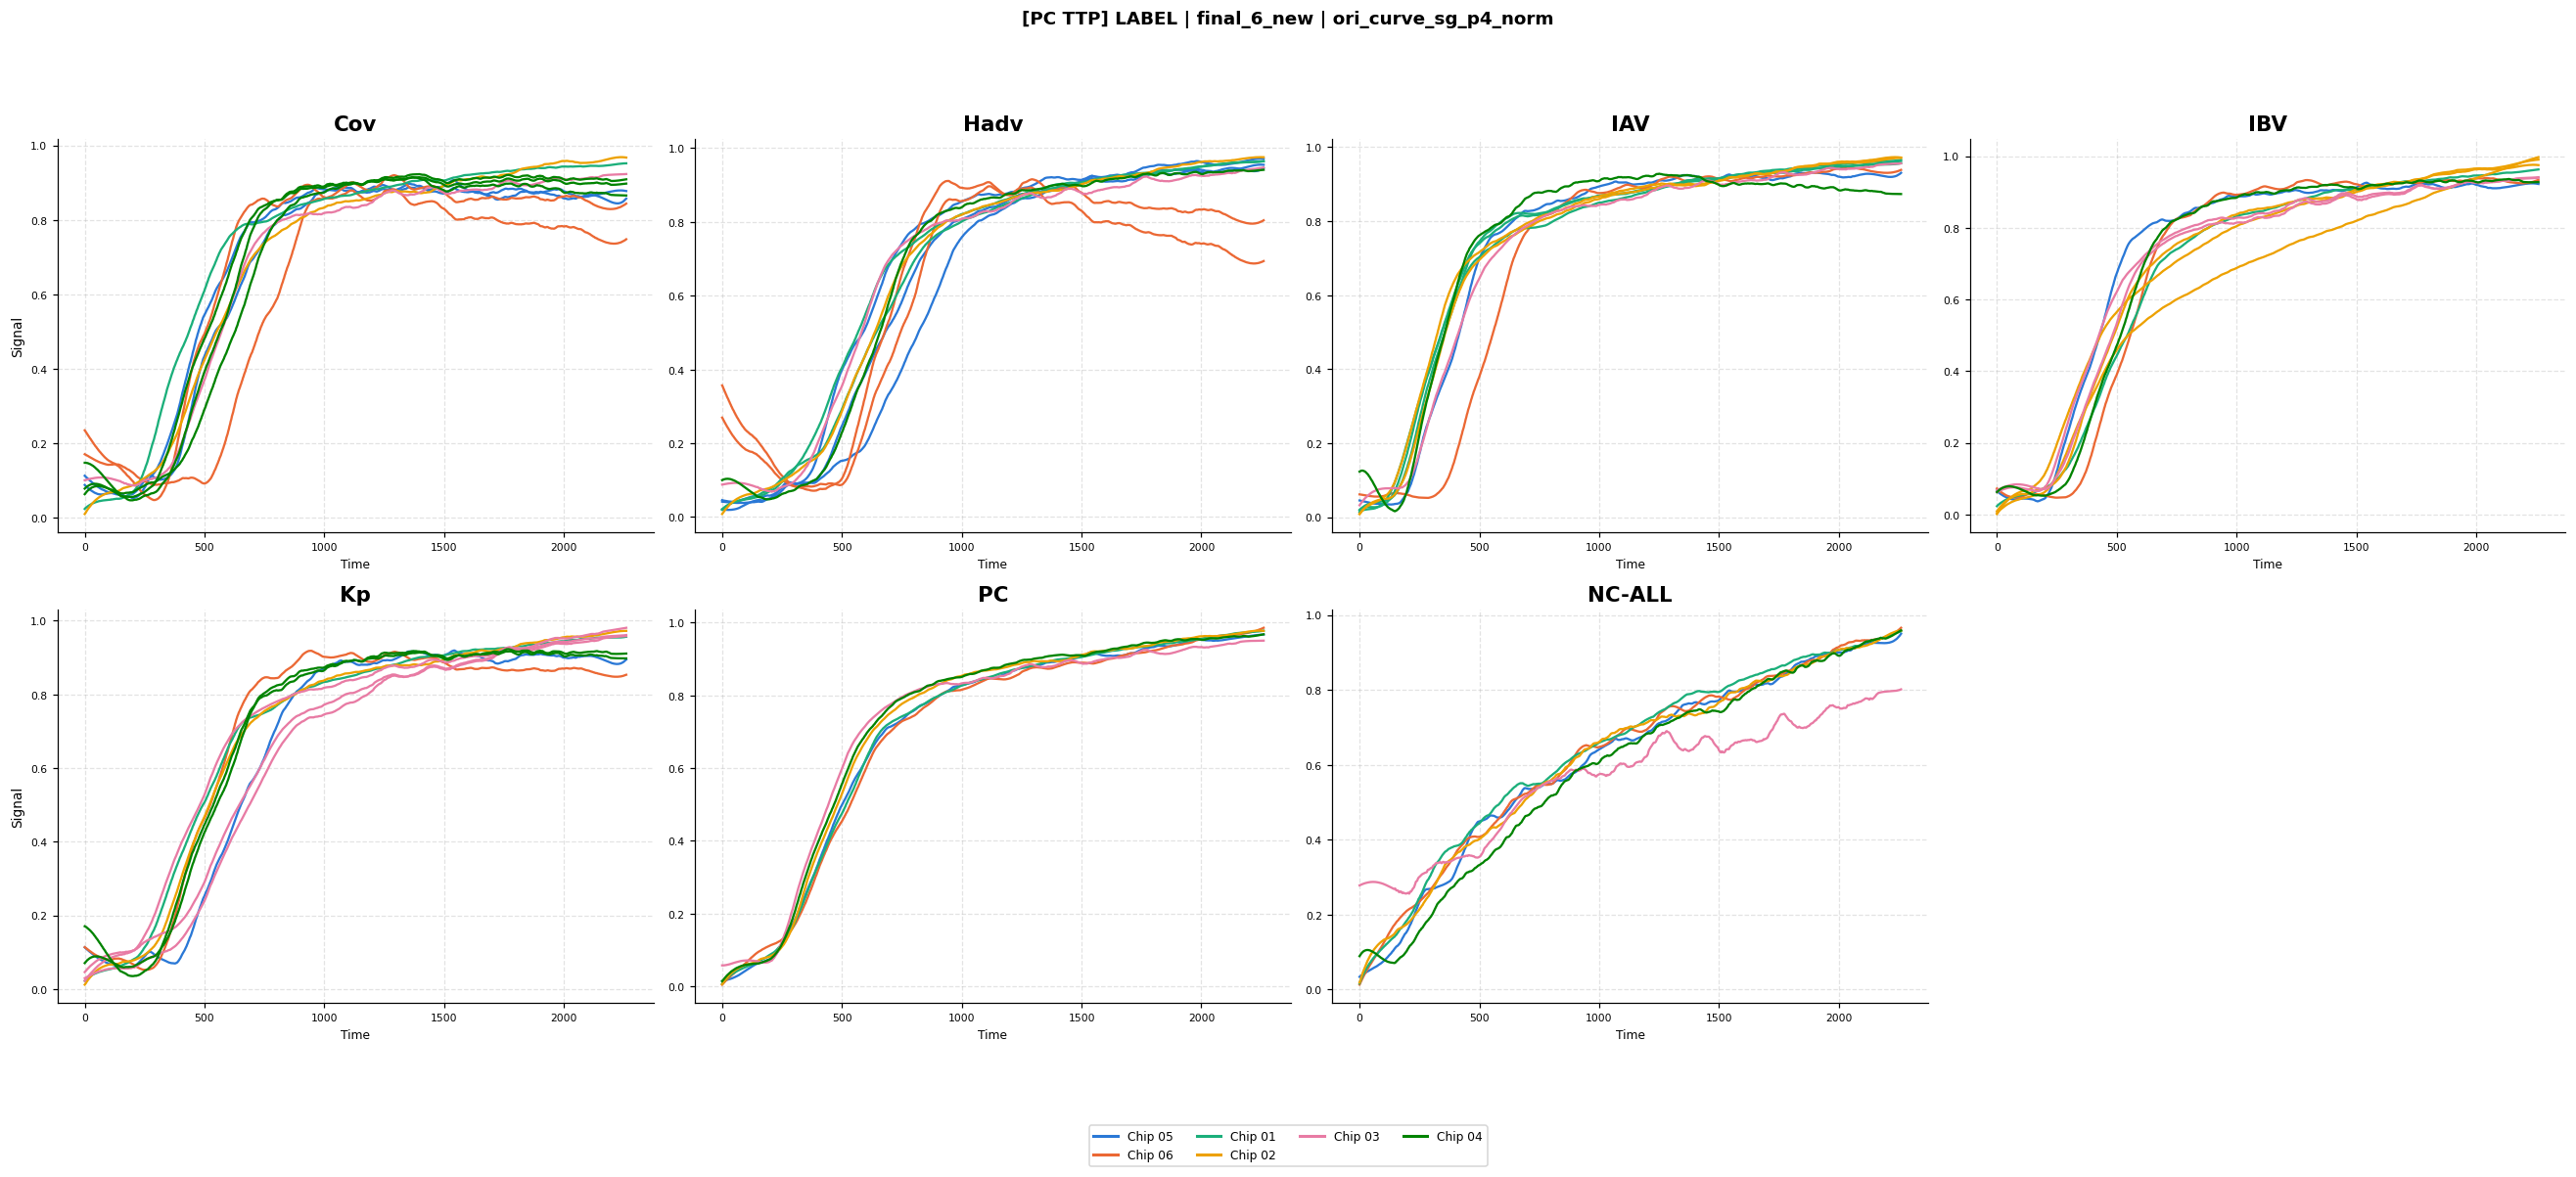

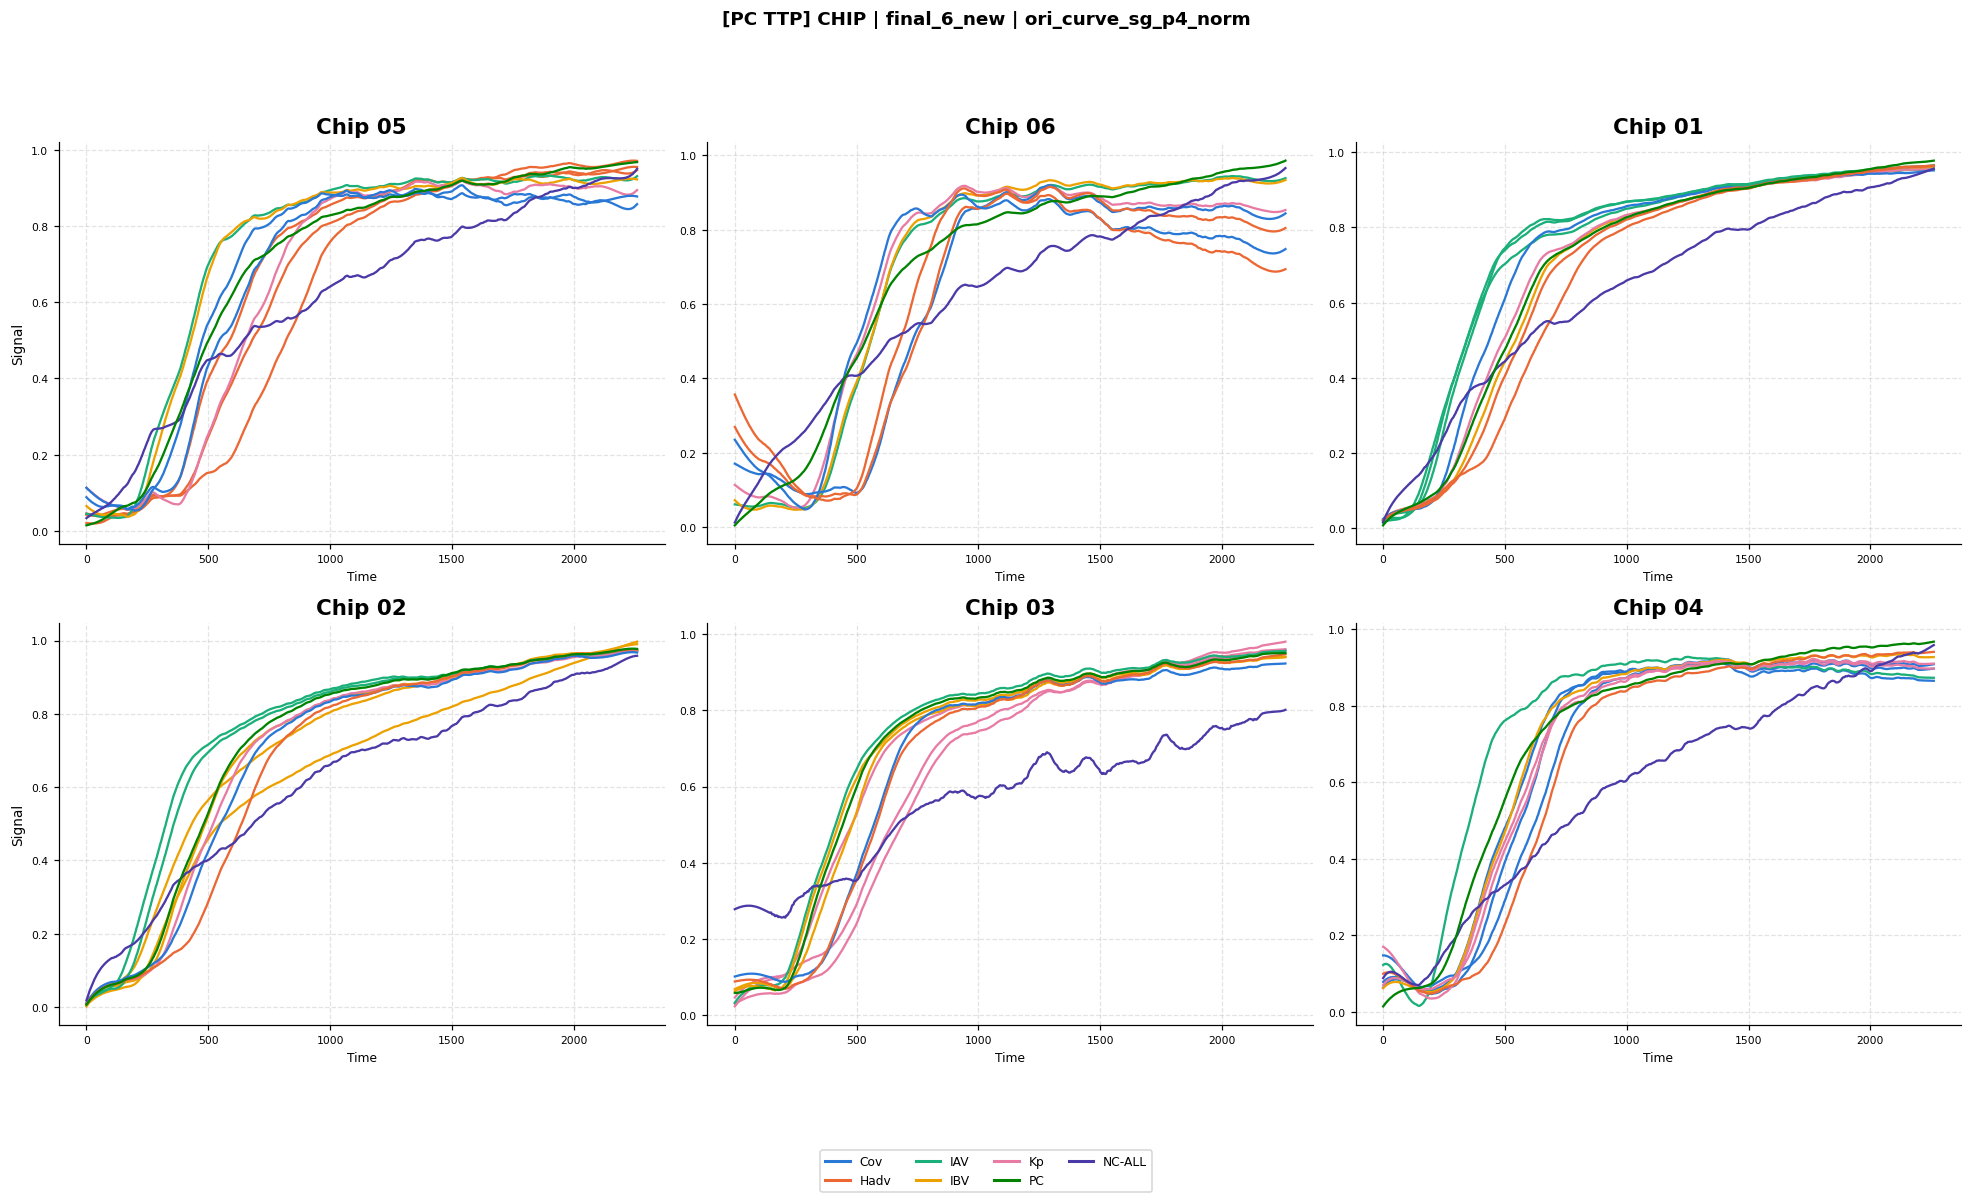

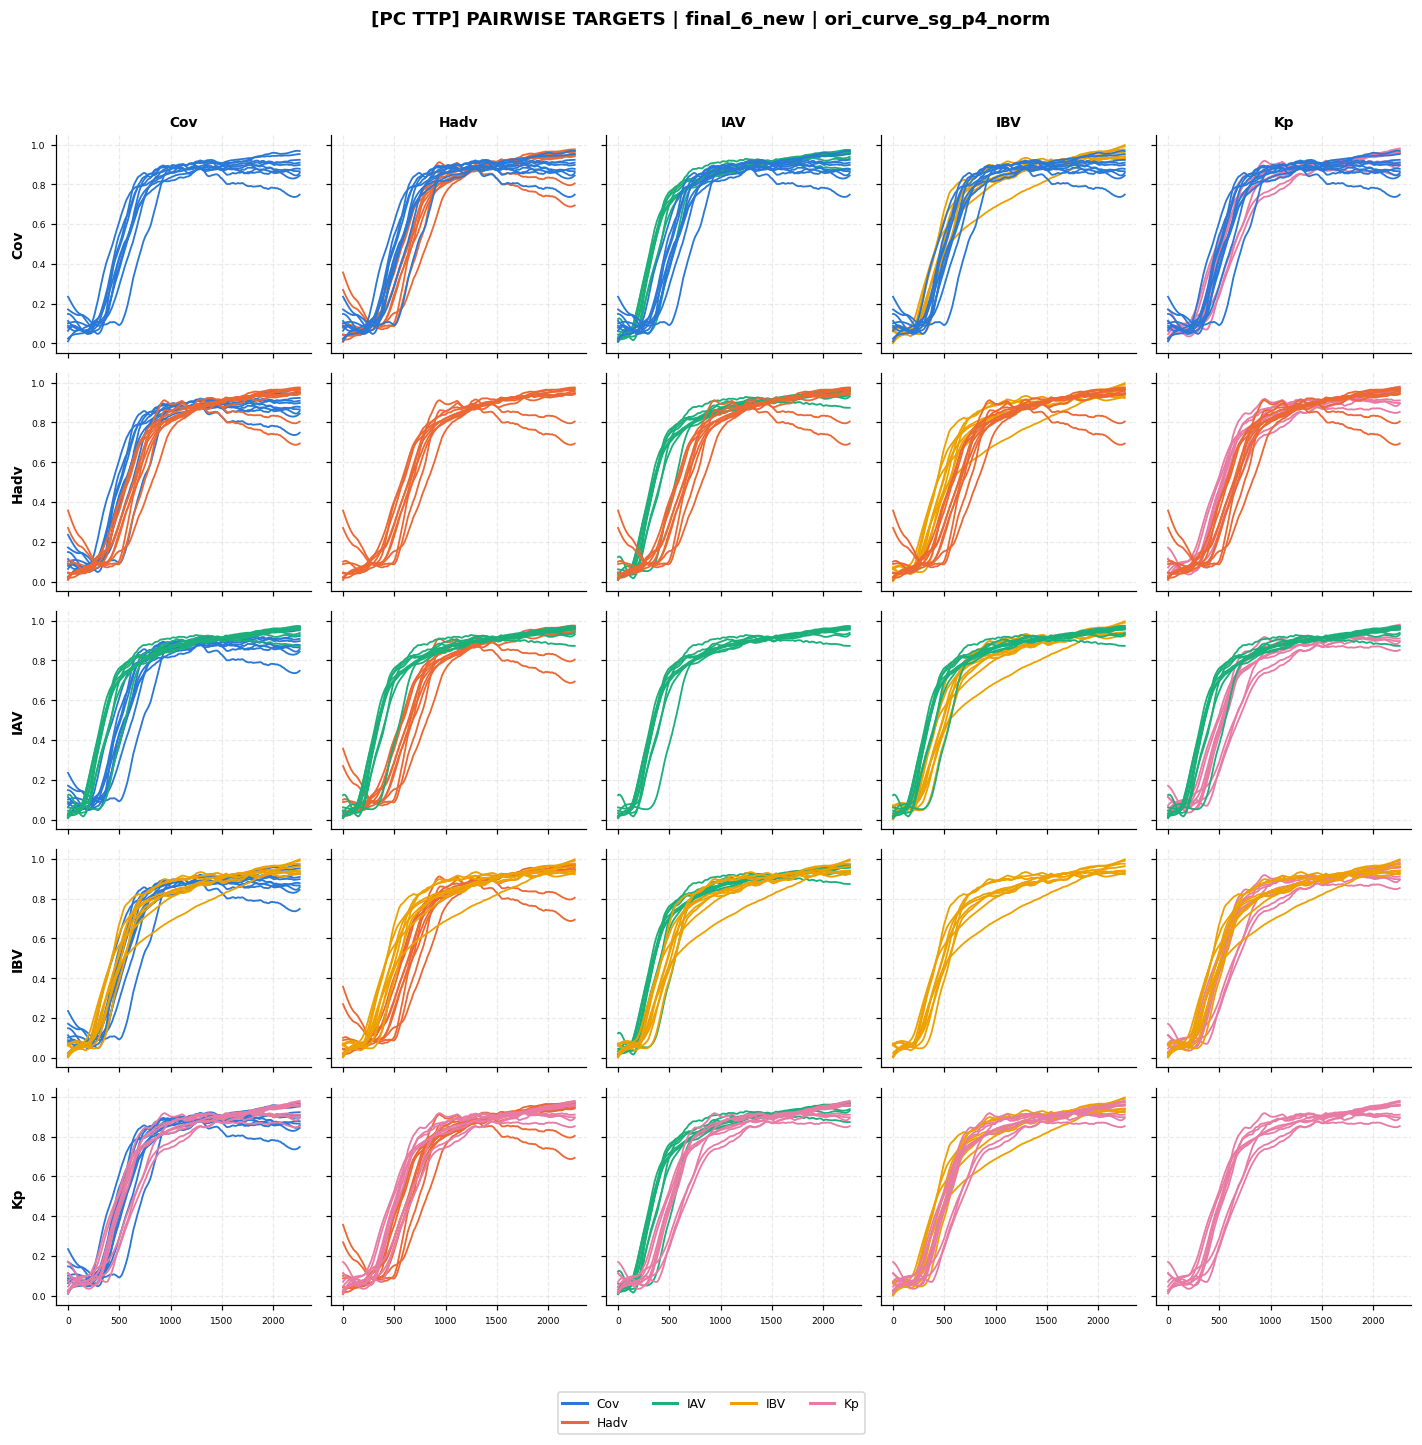

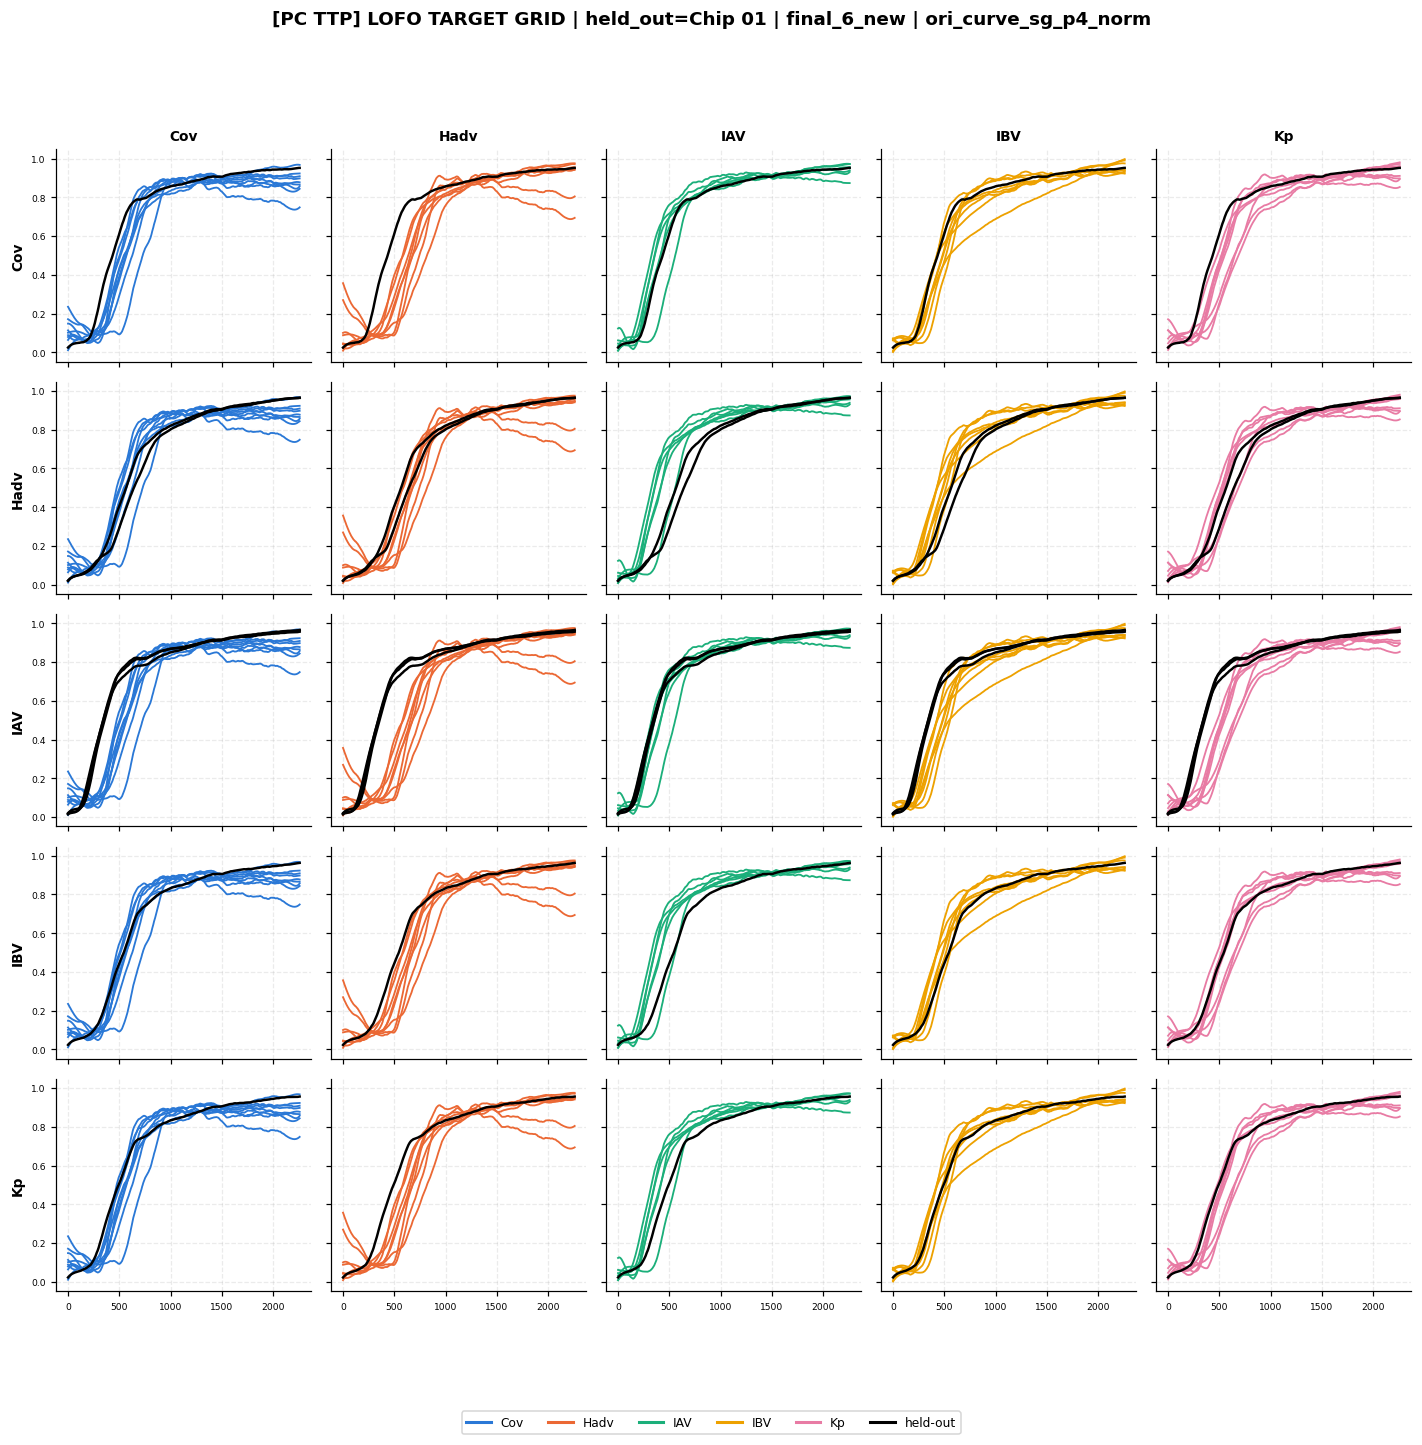

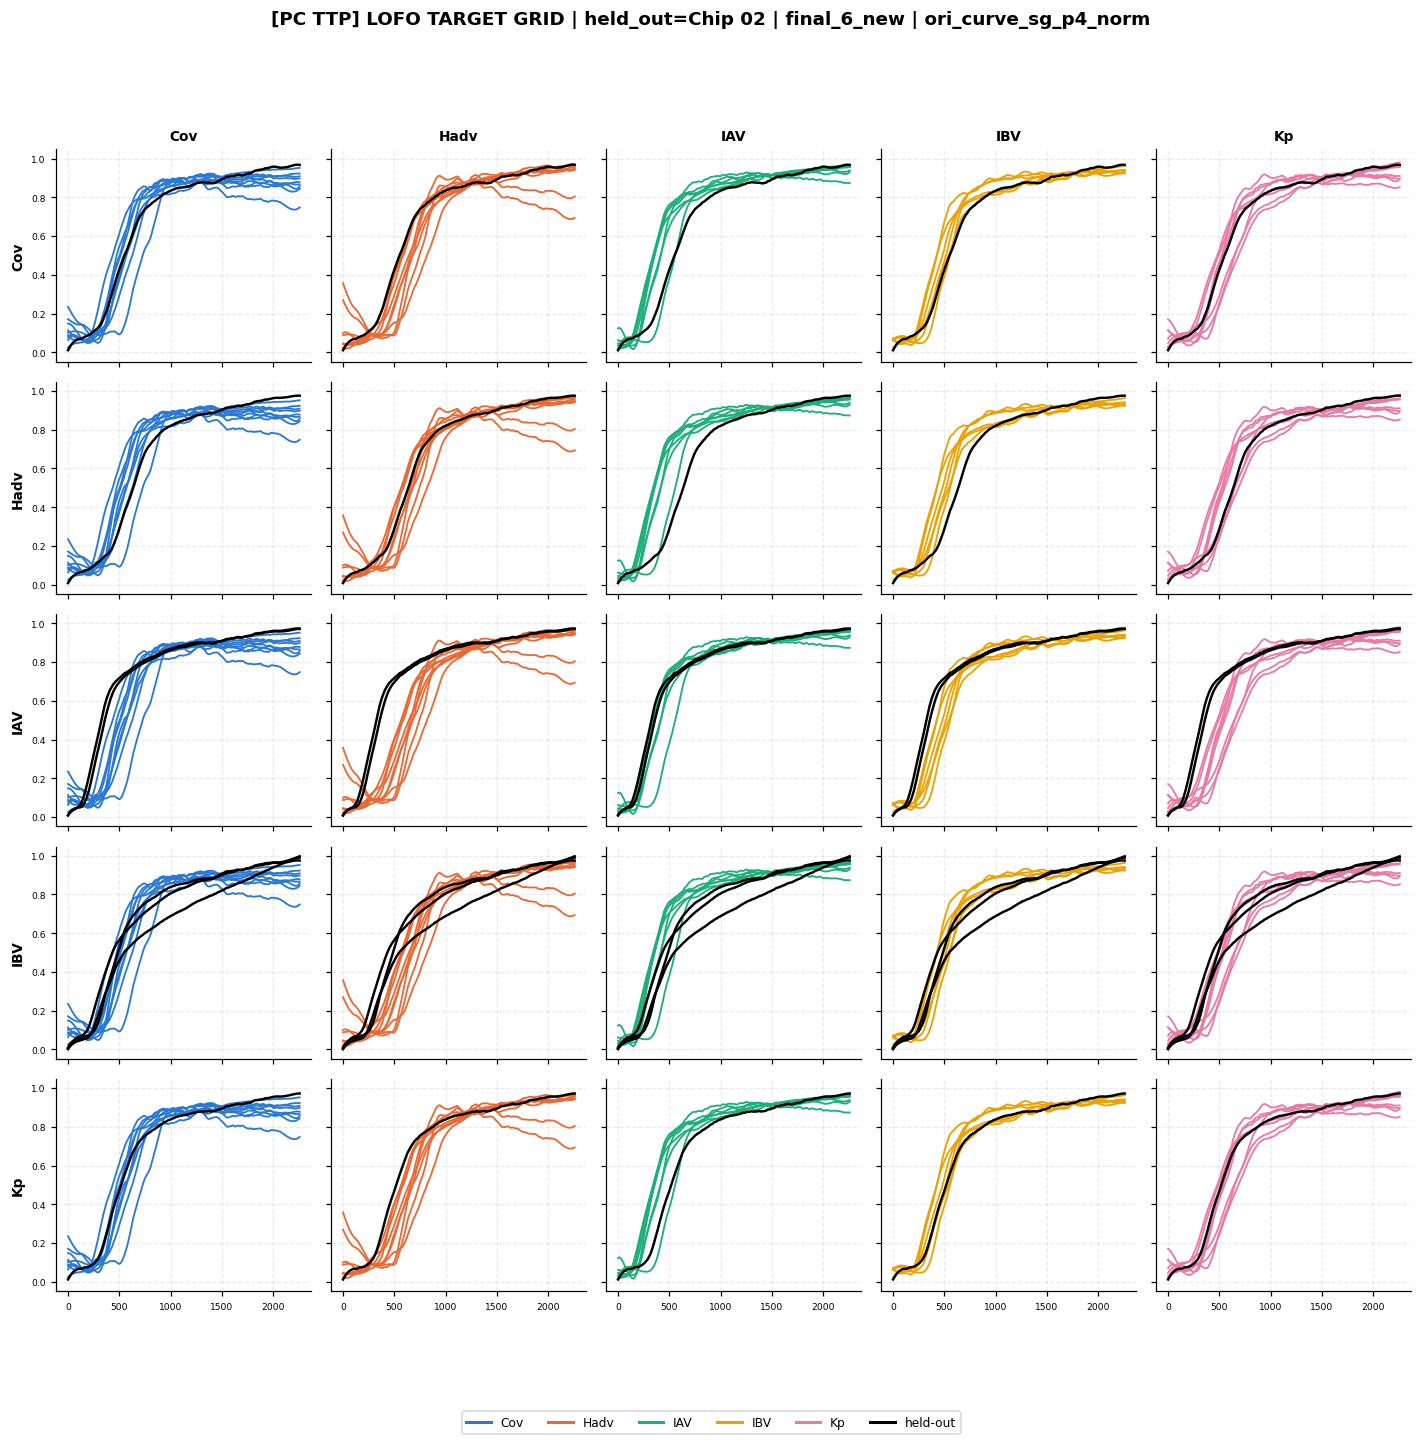

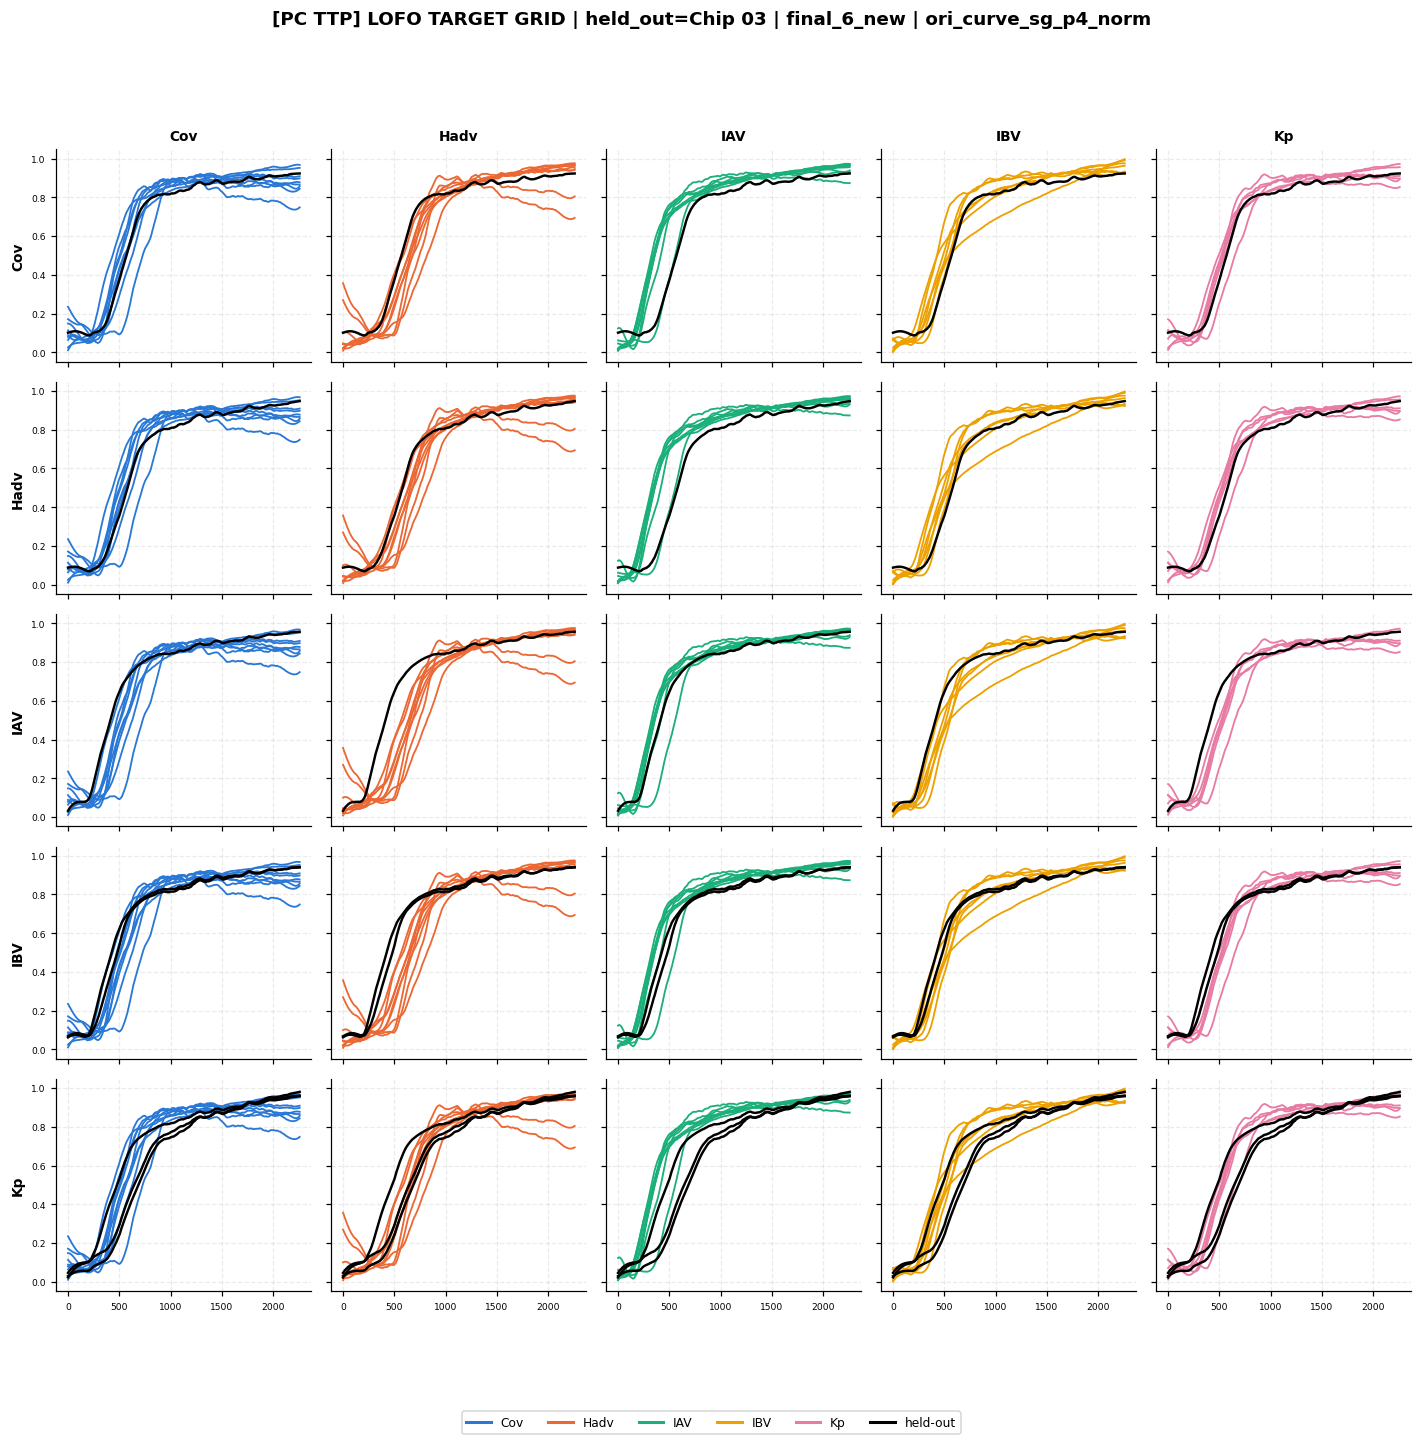

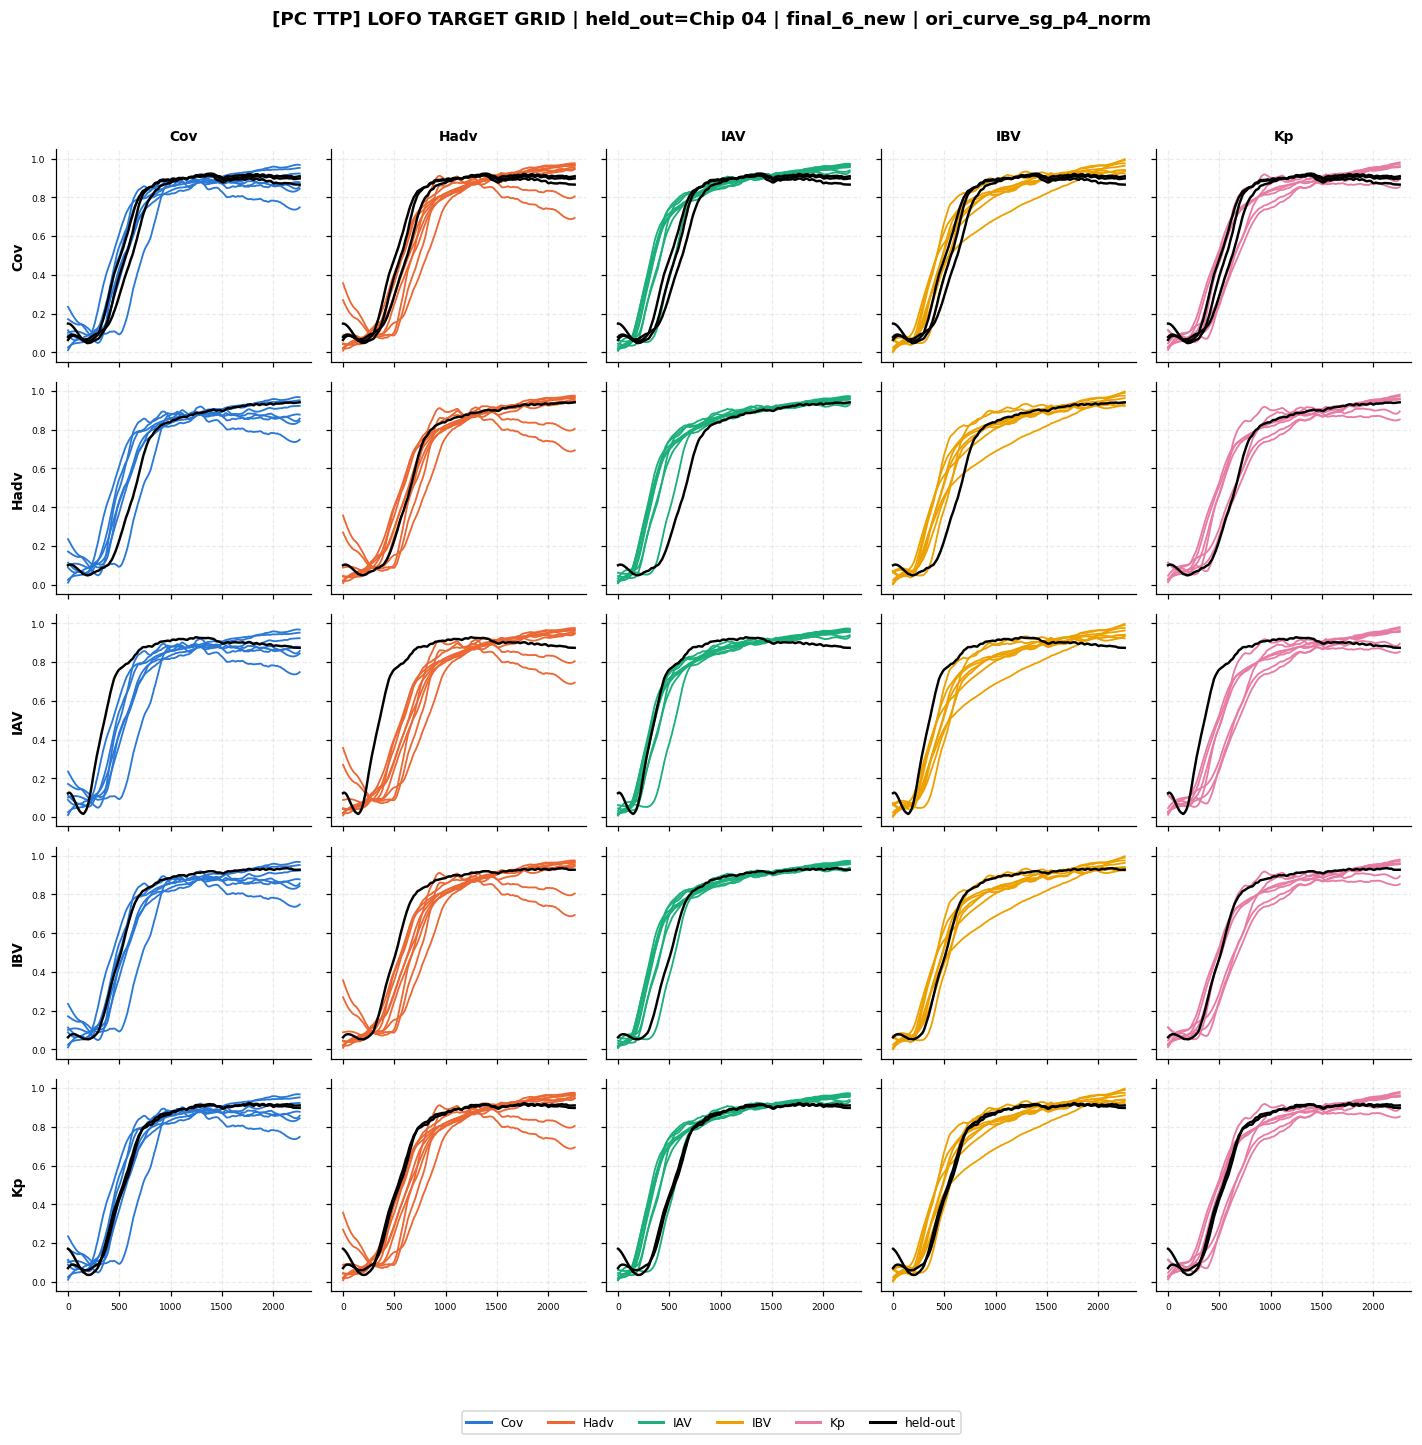

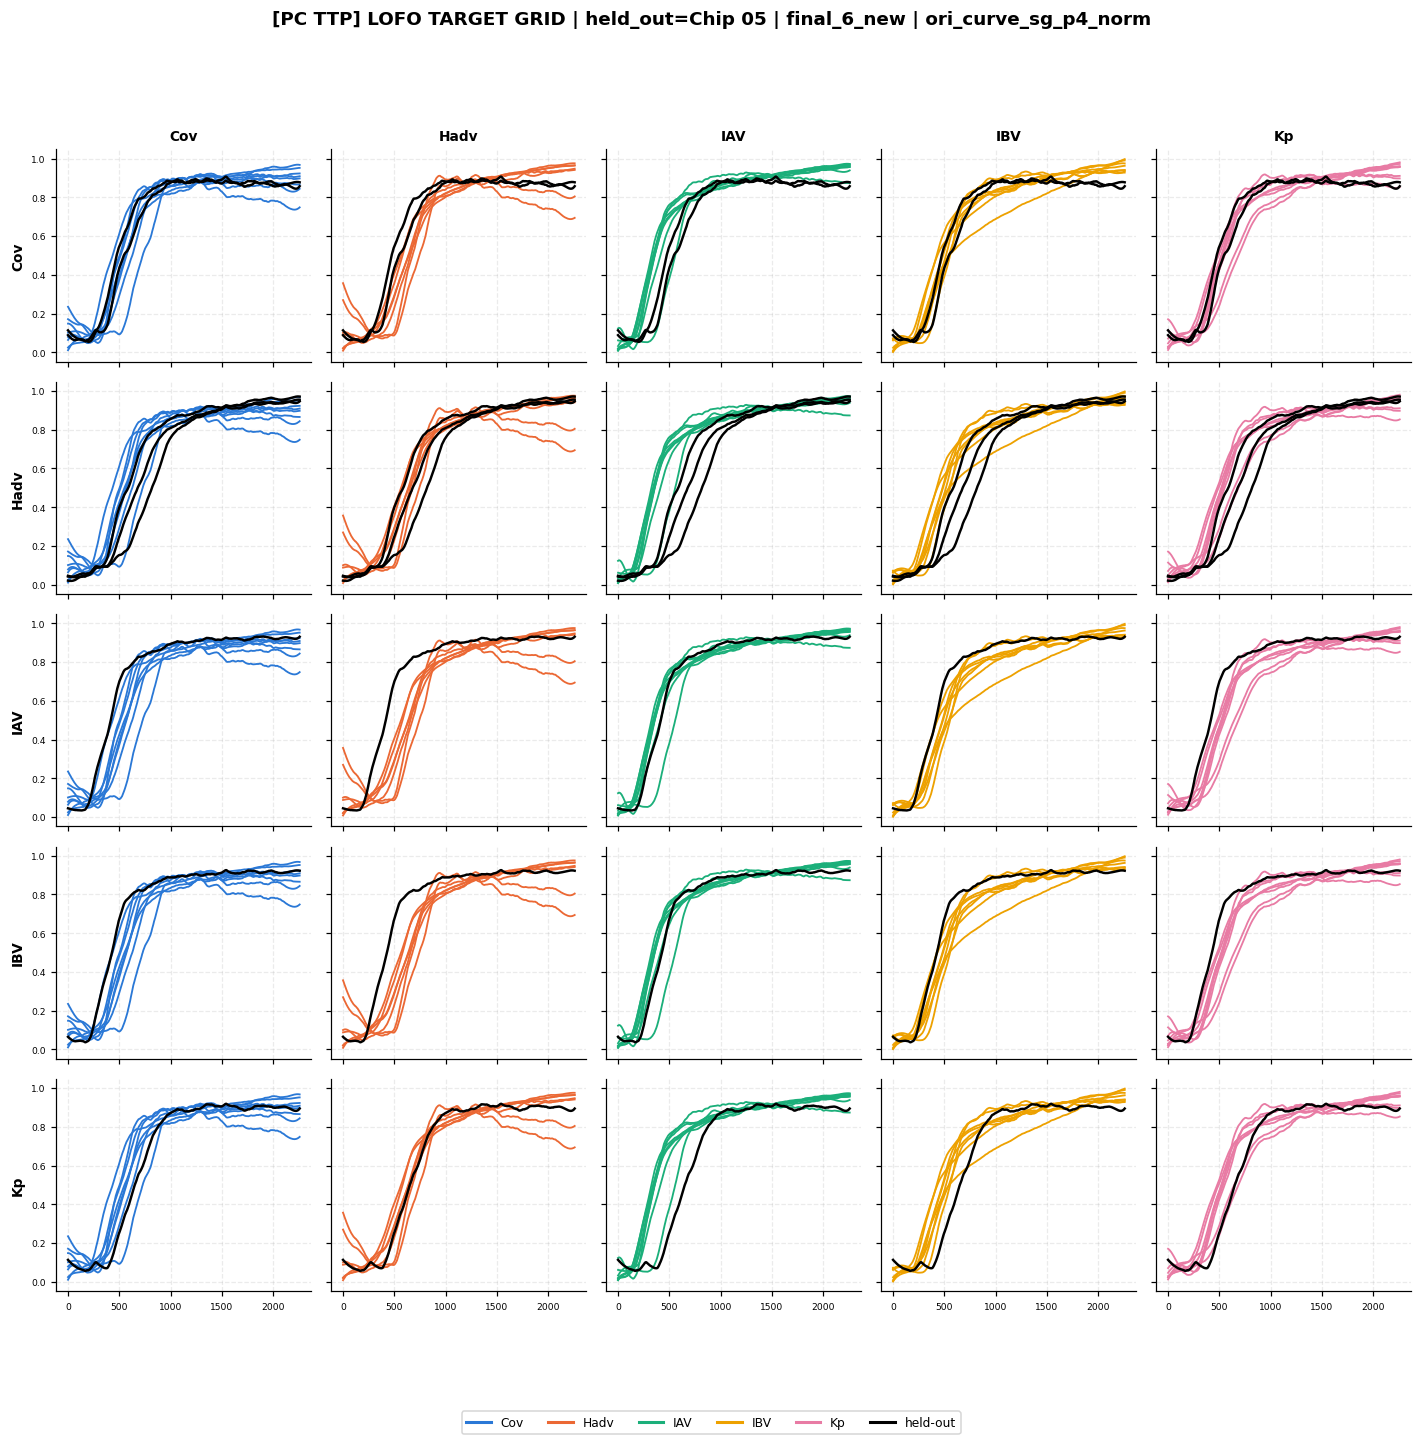

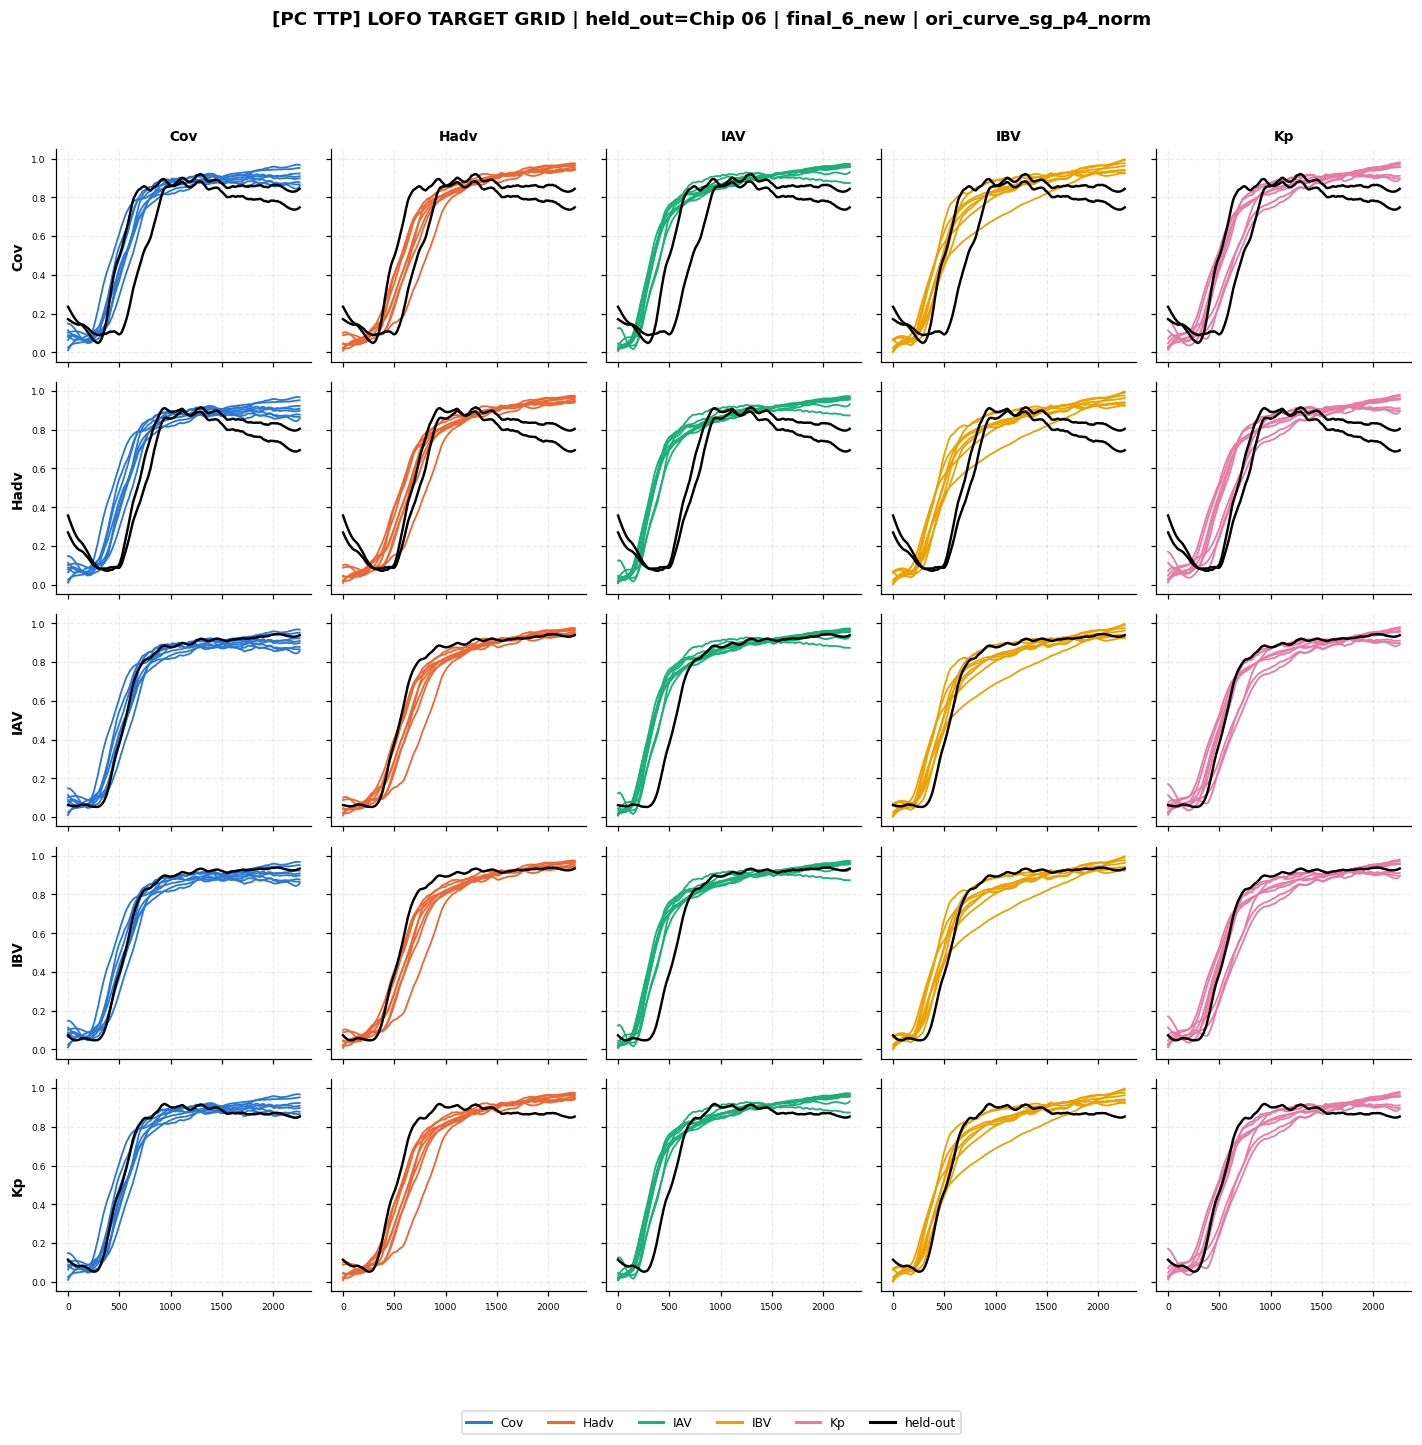

In [10]:
for CURVE_TYPE in CURVE_TYPES_TO_PLOT:
    print(f"\n{'='*90}\nCURVE_TYPE = {CURVE_TYPE}\n{'='*90}")

    # --- PC-TTP alignment, ALL chips together (no exclusion) -- "held out" is purely
    # a post-hoc visualization split below, not a separate alignment computation.
    combined = build_pool(None, CURVE_TYPE)
    combined_pc_nc = with_nc_added_pc_ttp(
        with_pc_added_pc_ttp(combined, exp_paths, CURVE_TYPE), exp_paths, CURVE_TYPE)
    # Per-curve min-max to [0,1] AFTER PC/NC are merged in -- combine_group_pc_aligned
    # only does this internally for _norm curve types, and before PC/NC are added, so
    # this is the only path that normalizes PC/NC too and covers the plain curve type.
    combined_pc_nc["curves"] = cdt.normalize_curves_minmax(combined_pc_nc["curves"])

    plot_target_across_chips(
        combined_pc_nc,
        title=f"[PC TTP] LABEL | {GROUP_NAME} | {CURVE_TYPE}",
        with_all_curves=False,
    )
    plot_chip_across_targets(
        combined_pc_nc,
        title=f"[PC TTP] CHIP | {GROUP_NAME} | {CURVE_TYPE}",
        with_all_curves=False,
    )
    # plot_all_targets_all_chips(
    #     combined_pc_nc,
    #     title=f"[PC TTP] ALL TARGETS x ALL CHIPS | {GROUP_NAME} | {CURVE_TYPE}",
    #     with_all_curves=False,
    # )
    plot_target_pairwise_grid(
        combined_pc_nc,
        title=f"[PC TTP] PAIRWISE TARGETS | {GROUP_NAME} | {CURVE_TYPE}",
        with_all_curves=False,
    )
    # Reuses this same combined_pc_nc (built once above, all chips together) for
    # every candidate held-out chip -- cheap dataframe filtering per figure, no
    # repeat build_pool/PC-TTP-alignment calls.
    if CURVE_TYPE == "ori_curve_sg_p4_norm":
        for lofo_held_out in folder_names:
            plot_target_pairwise_grid_lofo(
                combined_pc_nc, held_out_chip=lofo_held_out,
                title=f"[PC TTP] LOFO TARGET GRID | held_out={short_name(lofo_held_out)} | {GROUP_NAME} | {CURVE_TYPE}",
                with_all_curves=False,
            )

    # # --- acquisition_start alignment, single pool ---
    # combined_acq = cdt.combine_group(exp_paths, GROUP_NAME, CURVE_TYPE)
    # combined_acq_pc_nc = with_nc_added(with_pc_added(combined_acq, exp_paths, CURVE_TYPE), exp_paths, CURVE_TYPE)
    # # acquisition_start path never normalizes internally (unlike PC-TTP's conditional
    # # _norm-curve-type case) -- always apply it explicitly here for consistency.
    # combined_acq_pc_nc["curves"] = cdt.normalize_curves_minmax(combined_acq_pc_nc["curves"])

    # plot_target_across_chips(
    #     combined_acq_pc_nc,
    #     title=f"[ACQUISITION_START] LABEL | {GROUP_NAME} | {CURVE_TYPE}",
    #     with_all_curves=False,
    # )
    # plot_chip_across_targets(
    #     combined_acq_pc_nc,
    #     title=f"[ACQUISITION_START] CHIP | {GROUP_NAME} | {CURVE_TYPE}",
    #     with_all_curves=False,
    # )
    # # plot_all_targets_all_chips(
    # #     combined_acq_pc_nc,
    # #     title=f"[ACQUISITION_START] ALL TARGETS x ALL CHIPS | {GROUP_NAME} | {CURVE_TYPE}",
    # #     with_all_curves=False,
    # # )
    # plot_target_pairwise_grid(
    #     combined_acq_pc_nc,
    #     title=f"[ACQUISITION_START] PAIRWISE TARGETS | {GROUP_NAME} | {CURVE_TYPE}",
    #     with_all_curves=False,
    # )